  TREE MODELS LAB — BREAST CANCER DATASET
Train: (455, 30) | Test: (114, 30)
Features: 30 | Classes: ['malignant' 'benign']

──────────────────────────────────────────────────
  STEP 1: Unpruned Tree (No Depth Limit)
──────────────────────────────────────────────────
Depth         : 7
Leaves        : 19
Train Accuracy: 1.0000  ← OVERFIT!
Test Accuracy : 0.9123
Gap (Overfit) : 0.0877

──────────────────────────────────────────────────
  STEP 2: GridSearchCV for Best Hyperparameters
──────────────────────────────────────────────────
Best Params   : {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score : 0.9385

Pruned Tree Results:
  Depth         : 4
  Leaves        : 11
  Train Accuracy: 0.9868
  Test Accuracy : 0.9386
  Gap (Overfit) : 0.0482

──────────────────────────────────────────────────
  STEP 3: Random Forest — 100 Trees
──────────────────────────────────────────────────
  Test Accuracy : 0.9561
  F1-Score      : 0.9560
  AUC-ROC       : 0.9937
  OOB Sc

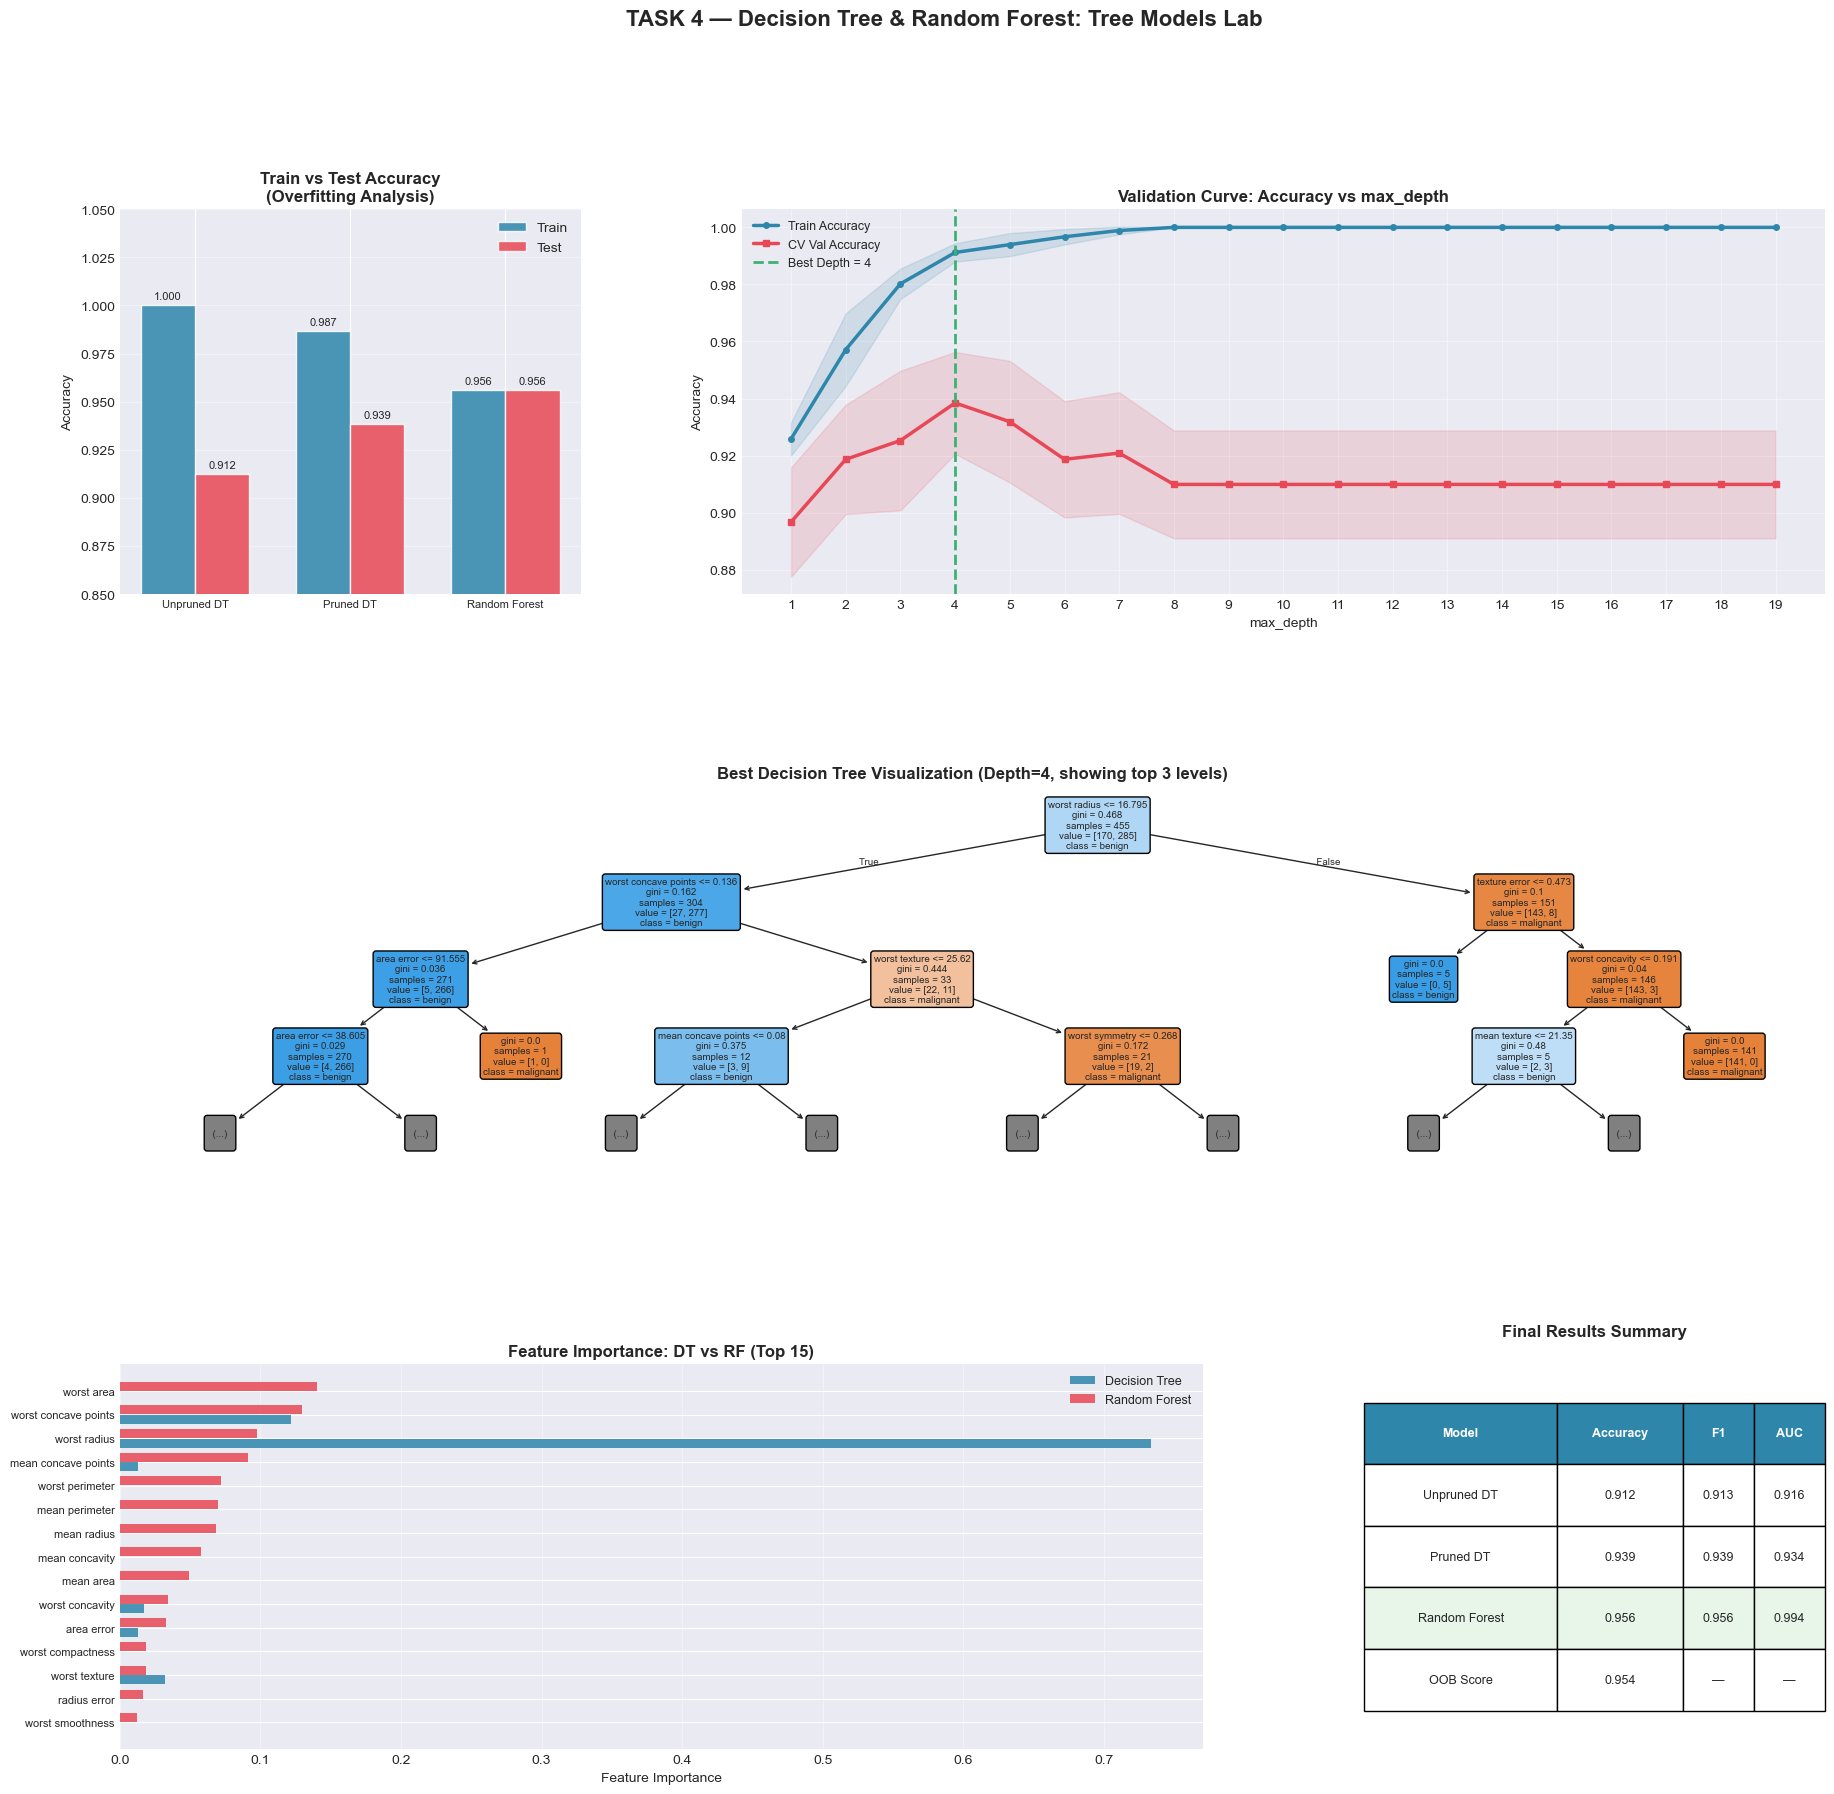


✅ TASK 4 COMPLETE — Decision Tree & Random Forest!


In [1]:
# ============================================================
# TASK 4: DECISION TREE & RANDOM FOREST — Tree Models Lab
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      validation_curve)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = ['#2E86AB','#E84855','#3BB273','#F4A261','#8338EC']

# ============================================================
# DATASET
# ============================================================

print("=" * 65)
print("  TREE MODELS LAB — BREAST CANCER DATASET")
print("=" * 65)

data     = load_breast_cancer()
X, y     = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Features: {X.shape[1]} | Classes: {data.target_names}")

# ============================================================
# STEP 1: UNPRUNED DECISION TREE — Observe Overfitting
# ============================================================

print("\n" + "─"*50)
print("  STEP 1: Unpruned Tree (No Depth Limit)")
print("─"*50)

dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

train_acc_full = accuracy_score(y_train, dt_full.predict(X_train))
test_acc_full  = accuracy_score(y_test,  dt_full.predict(X_test))

print(f"Depth         : {dt_full.get_depth()}")
print(f"Leaves        : {dt_full.get_n_leaves()}")
print(f"Train Accuracy: {train_acc_full:.4f}  ← OVERFIT!")
print(f"Test Accuracy : {test_acc_full:.4f}")
print(f"Gap (Overfit) : {train_acc_full - test_acc_full:.4f}")

# ============================================================
# STEP 2: PRE-PRUNING WITH GRIDSEARCHCV
# ============================================================

print("\n" + "─"*50)
print("  STEP 2: GridSearchCV for Best Hyperparameters")
print("─"*50)

param_grid = {
    'max_depth'        : [3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8],
}

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
gs.fit(X_train, y_train)

print(f"Best Params   : {gs.best_params_}")
print(f"Best CV Score : {gs.best_score_:.4f}")

dt_best = gs.best_estimator_
train_acc_best = accuracy_score(y_train, dt_best.predict(X_train))
test_acc_best  = accuracy_score(y_test,  dt_best.predict(X_test))

print(f"\nPruned Tree Results:")
print(f"  Depth         : {dt_best.get_depth()}")
print(f"  Leaves        : {dt_best.get_n_leaves()}")
print(f"  Train Accuracy: {train_acc_best:.4f}")
print(f"  Test Accuracy : {test_acc_best:.4f}")
print(f"  Gap (Overfit) : {train_acc_best - test_acc_best:.4f}")

# ============================================================
# STEP 3: RANDOM FOREST — 100 Trees
# ============================================================

print("\n" + "─"*50)
print("  STEP 3: Random Forest — 100 Trees")
print("─"*50)

rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_acc  = accuracy_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred, average='weighted')
rf_auc  = roc_auc_score(y_test, rf_prob)
rf_oob  = rf.oob_score_

print(f"  Test Accuracy : {rf_acc:.4f}")
print(f"  F1-Score      : {rf_f1:.4f}")
print(f"  AUC-ROC       : {rf_auc:.4f}")
print(f"  OOB Score     : {rf_oob:.4f}")

# DT Best metrics
dt_prob = dt_best.predict_proba(X_test)[:, 1]
dt_f1   = f1_score(y_test, dt_best.predict(X_test), average='weighted')
dt_auc  = roc_auc_score(y_test, dt_prob)

# ============================================================
# VALIDATION CURVES
# ============================================================

max_depths  = range(1, 20)
vc_train, vc_val = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    param_name='max_depth',
    param_range=max_depths,
    cv=5, scoring='accuracy', n_jobs=-1
)

# ============================================================
# ALL PLOTS
# ============================================================

fig = plt.figure(figsize=(22, 20))
fig.suptitle('TASK 4 — Decision Tree & Random Forest: Tree Models Lab',
             fontsize=16, fontweight='bold')
gs2 = gridspec.GridSpec(3, 3, hspace=0.5, wspace=0.35)

# Plot 1: Overfitting Analysis
ax1 = fig.add_subplot(gs2[0, 0])
models_list  = ['Unpruned DT', 'Pruned DT', 'Random Forest']
train_scores = [train_acc_full, train_acc_best, rf_acc]
test_scores  = [test_acc_full,  test_acc_best,  rf_acc]
x_pos = np.arange(3); bw = 0.35
ax1.bar(x_pos-bw/2, train_scores, bw, label='Train',
        color=COLORS[0], alpha=0.85, edgecolor='white')
ax1.bar(x_pos+bw/2, test_scores,  bw, label='Test',
        color=COLORS[1], alpha=0.85, edgecolor='white')
for i, (tr, te) in enumerate(zip(train_scores, test_scores)):
    ax1.text(i-bw/2, tr+0.003, f'{tr:.3f}', ha='center', fontsize=8)
    ax1.text(i+bw/2, te+0.003, f'{te:.3f}', ha='center', fontsize=8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models_list, fontsize=8)
ax1.set_ylim(0.85, 1.05)
ax1.set_title('Train vs Test Accuracy\n(Overfitting Analysis)',
              fontweight='bold')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.4, axis='y')

# Plot 2: Validation Curves
ax2 = fig.add_subplot(gs2[0, 1:])
train_mean = vc_train.mean(axis=1)
train_std  = vc_train.std(axis=1)
val_mean   = vc_val.mean(axis=1)
val_std    = vc_val.std(axis=1)

ax2.plot(list(max_depths), train_mean, COLORS[0], lw=2.5,
         marker='o', markersize=4, label='Train Accuracy')
ax2.fill_between(list(max_depths), train_mean-train_std,
                 train_mean+train_std, alpha=0.15, color=COLORS[0])
ax2.plot(list(max_depths), val_mean, COLORS[1], lw=2.5,
         marker='s', markersize=4, label='CV Val Accuracy')
ax2.fill_between(list(max_depths), val_mean-val_std,
                 val_mean+val_std, alpha=0.15, color=COLORS[1])
best_depth = gs.best_params_['max_depth'] or 'None'
ax2.axvline(dt_best.get_depth(), color=COLORS[2],
            linestyle='--', lw=2,
            label=f"Best Depth = {dt_best.get_depth()}")
ax2.set_xlabel('max_depth'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Curve: Accuracy vs max_depth', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)
ax2.set_xticks(list(max_depths))

# Plot 3: Best Tree Visualization
ax3 = fig.add_subplot(gs2[1, :])
plot_tree(dt_best,
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True, rounded=True,
          max_depth=3,       # show only first 3 levels
          fontsize=7,
          ax=ax3)
ax3.set_title(f'Best Decision Tree Visualization (Depth={dt_best.get_depth()}, '
              f'showing top 3 levels)', fontweight='bold')

# Plot 4: Feature Importance — DT vs RF
ax4 = fig.add_subplot(gs2[2, :2])
n_top = 15
dt_imp = dt_best.feature_importances_
rf_imp = rf.feature_importances_

# Sort by RF importance
idx_sorted = np.argsort(rf_imp)[-n_top:]
feat_names = [data.feature_names[i] for i in idx_sorted]
y_pos      = np.arange(n_top)

ax4.barh(y_pos - 0.2, dt_imp[idx_sorted], 0.38,
         label='Decision Tree', color=COLORS[0], alpha=0.85)
ax4.barh(y_pos + 0.2, rf_imp[idx_sorted], 0.38,
         label='Random Forest', color=COLORS[1], alpha=0.85)
ax4.set_yticks(y_pos)
ax4.set_yticklabels(feat_names, fontsize=8)
ax4.set_xlabel('Feature Importance')
ax4.set_title(f'Feature Importance: DT vs RF (Top {n_top})',
              fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.4, axis='x')

# Plot 5: Final Metrics Comparison
ax5 = fig.add_subplot(gs2[2, 2])
ax5.axis('off')
table_vals = [
    ['Model',        'Accuracy','F1',    'AUC'],
    ['Unpruned DT',  f'{test_acc_full:.3f}',
     f'{f1_score(y_test,dt_full.predict(X_test),average="weighted"):.3f}',
     f'{roc_auc_score(y_test,dt_full.predict_proba(X_test)[:,1]):.3f}'],
    ['Pruned DT',    f'{test_acc_best:.3f}',
     f'{dt_f1:.3f}', f'{dt_auc:.3f}'],
    ['Random Forest',f'{rf_acc:.3f}',
     f'{rf_f1:.3f}', f'{rf_auc:.3f}'],
    ['OOB Score',    f'{rf_oob:.3f}', '—', '—'],
]
tbl = ax5.table(cellText=table_vals[1:], colLabels=table_vals[0],
                cellLoc='center', loc='center',
                bbox=[0, 0.1, 1, 0.8])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(4)))
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2E86AB')
        cell.set_text_props(color='white', fontweight='bold')
    elif r == 3:  # RF row
        cell.set_facecolor('#E8F5E9')
ax5.set_title('Final Results Summary', fontweight='bold', pad=20)

plt.show()
print("\n✅ TASK 4 COMPLETE — Decision Tree & Random Forest!")